Caption numbers for Fig. 5:
- 50% critical upgrades save US$32.5 million relative to full actuation (US$32.5 million vs US$65.0 million).
- Critical 30% increases speed by 18.5% relative to fixed-time control.
- Moving from Critical 30% to full actuation adds only 4.1 percentage points of speed improvement.


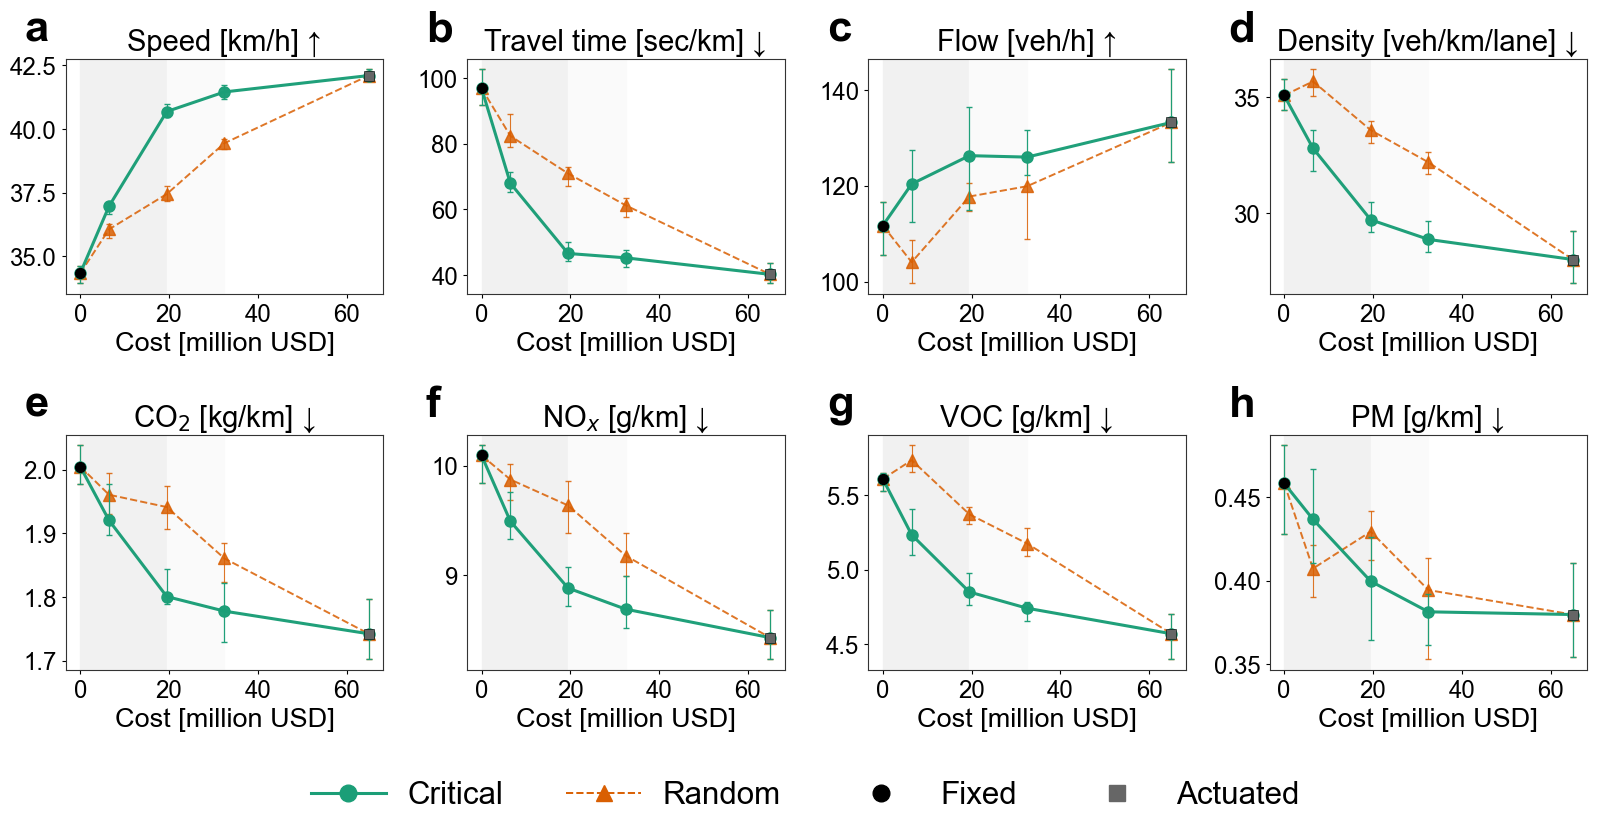

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# =========================================================
# 1. User inputs
# =========================================================

n_total_candidates = 1000   # <-- replace with len(candidate_intersections)
unit_cost_base = 65_000     # USD per upgraded intersection
save_path = "../figure/fig5_panel.pdf"


# =========================================================
# 2. Scenario setup
# =========================================================

scenario_map = {
    "Fix": {"plan": "Fix", "fraction": 0.00, "method": "Fix"},
    "Actuated": {"plan": "Actuated", "fraction": 1.00, "method": "Actuated"},

    "Random 10%": {"plan": "Random_0.1", "fraction": 0.10, "method": "Random"},
    "Random 30%": {"plan": "Random_0.5", "fraction": 0.30, "method": "Random"},
    "Random 50%": {"plan": "Random_1", "fraction": 0.50, "method": "Random"},

    "Critical 10%": {"plan": "Critical_0.1", "fraction": 0.10, "method": "Critical"},
    "Critical 30%": {"plan": "Critical_0.5", "fraction": 0.30, "method": "Critical"},
    "Critical 50%": {"plan": "Critical_1", "fraction": 0.50, "method": "Critical"},
}

critical_path = ["Fix", "Critical 10%", "Critical 30%", "Critical 50%", "Actuated"]
random_path   = ["Fix", "Random 10%", "Random 30%", "Random 50%", "Actuated"]


# =========================================================
# 3. Metrics
# =========================================================

metrics = {
    "Speed [km/h]": {
        "col": "speed",
        "scale": 1.0,
        "better": "higher",
    },
    "Travel time [sec/km]": {
        "col": "ttime",
        "scale": 1.0,
        "better": "lower",
    },
    "Flow [veh/h]": {
        "col": "flow",
        "scale": 1.0,
        "better": "higher",
    },
    "Density [veh/km/lane]": {
        "col": "density",
        "scale": 1.0,
        "better": "lower",
    },
    "CO$_2$ [kg/km]": {
        "col": "CO2_interurban",
        "scale": 1 / 1000,
        "better": "lower",
    },
    "NO$_x$ [g/km]": {
        "col": "NOx_interurban",
        "scale": 1.0,
        "better": "lower",
    },
    "VOC [g/km]": {
        "col": "VOC_interurban",
        "scale": 1.0,
        "better": "lower",
    },
    "PM [g/km]": {
        "col": "PM_interurban",
        "scale": 1.0,
        "better": "lower",
    },
}


# =========================================================
# 4. Load metric values
# =========================================================

def load_metric_by_rep(plan_name, col, scale=1.0):
    """
    Return one metric value per rep.
    Each rep value is averaged over all links and all times.
    rep = -1 is excluded.
    """
    path = f"../data/processed/{plan_name}_aimsun.parquet"
    df = pd.read_parquet(path)

    df = df[df["rep"] != -1].copy()

    out = (
        df.groupby("rep")[col]
          .mean()
          .reset_index()
          .rename(columns={col: "value"})
    )

    out["value"] = out["value"] * scale
    return out


def summarize_metric(plan_name, col, scale=1.0):
    """
    Return median and IQR across repetitions.
    """
    df = load_metric_by_rep(plan_name, col, scale)
    vals = df["value"].to_numpy()

    p25, p50, p75 = np.nanpercentile(vals, [25, 50, 75])

    return {
        "median": p50,
        "lo": p50 - p25,
        "hi": p75 - p50,
    }


# =========================================================
# 5. Build plotting table
# =========================================================

rows = []

for scenario_name, spec in scenario_map.items():
    n_controlled = int(round(n_total_candidates * spec["fraction"]))
    cost_million = n_controlled * unit_cost_base / 1e6

    for metric_label, m in metrics.items():
        stat = summarize_metric(
            plan_name=spec["plan"],
            col=m["col"],
            scale=m["scale"]
        )

        rows.append({
            "scenario": scenario_name,
            "method": spec["method"],
            "plan": spec["plan"],
            "fraction": spec["fraction"],
            "n_controlled": n_controlled,
            "cost_million": cost_million,
            "metric_label": metric_label,
            "better": m["better"],
            "y": stat["median"],
            "lo": stat["lo"],
            "hi": stat["hi"],
        })

df_plot = pd.DataFrame(rows)


# =========================================================
# 6. Caption numbers for investment and diminishing returns
# =========================================================

def get_metric_value(scenario, metric_label):
    row = df_plot[(df_plot["scenario"] == scenario) & (df_plot["metric_label"] == metric_label)].iloc[0]
    return float(row["y"])


def percent_improvement(value, baseline, better):
    if better == "higher":
        return (value - baseline) / baseline * 100
    if better == "lower":
        return (baseline - value) / baseline * 100
    raise ValueError("better must be 'higher' or 'lower'.")


full_investment_musd = n_total_candidates * unit_cost_base / 1e6
critical_50_investment_musd = n_total_candidates * 0.50 * unit_cost_base / 1e6
investment_saving_musd = full_investment_musd - critical_50_investment_musd

speed_label = "Speed [km/h]"
speed_better = metrics[speed_label]["better"]
speed_fix = get_metric_value("Fix", speed_label)
speed_critical_30 = get_metric_value("Critical 30%", speed_label)
speed_actuated = get_metric_value("Actuated", speed_label)

speed_improvement_critical_30_pct = percent_improvement(
    speed_critical_30,
    speed_fix,
    speed_better,
)
speed_improvement_actuated_pct = percent_improvement(
    speed_actuated,
    speed_fix,
    speed_better,
)
speed_extra_full_after_30_pp = speed_improvement_actuated_pct - speed_improvement_critical_30_pct

caption_numbers = {
    "full_investment_musd": full_investment_musd,
    "critical_50_investment_musd": critical_50_investment_musd,
    "investment_saving_musd": investment_saving_musd,
    "speed_fix_kmh": speed_fix,
    "speed_critical_30_kmh": speed_critical_30,
    "speed_actuated_kmh": speed_actuated,
    "speed_improvement_critical_30_pct": speed_improvement_critical_30_pct,
    "speed_extra_full_after_30_pp": speed_extra_full_after_30_pp,
}

print("Caption numbers for Fig. 5:")
print(f"- 50% critical upgrades save US${investment_saving_musd:.1f} million relative to full actuation "
      f"(US${critical_50_investment_musd:.1f} million vs US${full_investment_musd:.1f} million).")
print(f"- Critical 30% increases speed by {speed_improvement_critical_30_pct:.1f}% relative to fixed-time control.")
print(f"- Moving from Critical 30% to full actuation adds only {speed_extra_full_after_30_pp:.1f} percentage points of speed improvement.")


# =========================================================
# 7. Plot style
# =========================================================

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "mathtext.fontset": "dejavusans",
    "font.size": 18.75,
    "axes.labelsize": 19.5,
    "axes.titlesize": 21.0,
    "xtick.labelsize": 17.25,
    "ytick.labelsize": 17.25,
    "legend.fontsize": 22.5,
    "axes.linewidth": 0.8,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

colors = {
    "Critical": "#1b9e77",
    "Random": "#d95f02",
    "Fix": "black",
    "Actuated": "#666666",
}


# =========================================================
# 8. Plot
# =========================================================

fig, axes = plt.subplots(2, 4, figsize=(16.2, 7.8))
axes = axes.ravel()

panel_labels = list("abcdefgh")

for i, (ax, metric_label) in enumerate(zip(axes, metrics.keys())):

    sub = df_plot[df_plot["metric_label"] == metric_label].copy()

    C = sub.set_index("scenario").loc[critical_path].reset_index()
    R = sub.set_index("scenario").loc[random_path].reset_index()

    max_cost = sub["cost_million"].max()
    cost_30 = n_total_candidates * 0.30 * unit_cost_base / 1e6
    cost_50 = n_total_candidates * 0.50 * unit_cost_base / 1e6

    # ===== Cost-range backgrounds =====
    ax.set_facecolor("white")
    ax.axvspan(
        0,
        cost_30,
        color="#F1F1F1",
        zorder=0,
    )
    ax.axvspan(
        cost_30,
        cost_50,
        color="#FAFAFA",
        zorder=0,
    )

    # ===== Random path =====
    ax.errorbar(
        R["cost_million"], R["y"],
        yerr=[R["lo"], R["hi"]],
        color=colors["Random"],
        marker="^",
        linestyle="--",
        linewidth=1.4,
        markersize=8.0,
        elinewidth=0.8,
        capsize=2.2,
        alpha=0.85,
        label="Random",
        zorder=3,
    )

    # ===== Critical path =====
    ax.errorbar(
        C["cost_million"], C["y"],
        yerr=[C["lo"], C["hi"]],
        color=colors["Critical"],
        marker="o",
        linewidth=2.2,
        markersize=8,
        elinewidth=0.9,
        capsize=2.4,
        alpha=0.98,
        label="Critical",
        zorder=5,
    )

    # ===== Fix and Actuated endpoints =====
    fix = sub[sub["scenario"] == "Fix"].iloc[0]
    act = sub[sub["scenario"] == "Actuated"].iloc[0]

    ax.scatter(
        fix["cost_million"], fix["y"],
        color=colors["Fix"],
        s=50,
        marker="o",
        zorder=6,
    )

    ax.scatter(
        act["cost_million"], act["y"],
        color=colors["Actuated"],
        marker="s",
        s=56,
        edgecolor="black",
        linewidth=0.4,
        zorder=6,
    )

    # ===== better direction label =====
    better = sub["better"].iloc[0]

    # ax.text(
    #     0.98, 0.9,
    #     "higher is better" if better == "higher" else "lower is better",
    #     transform=ax.transAxes,
    #     fontsize=9,
    #     color="#444444",
    #     ha="right",
    #     va="top",
    #     bbox=dict(facecolor="white", edgecolor="none", alpha=0.72, pad=1.4),
    #     zorder=20,
    # )

    # ===== Panel label =====
    ax.text(
        -0.13, 1.04,
        panel_labels[i],
        transform=ax.transAxes,
        fontsize=31.5,
        fontfamily="Arial",
        fontweight="heavy",
        color="black",
        ha="left",
        va="bottom",
        clip_on=False,
    )

    # ===== Title =====
    arrow = "↑" if better == "higher" else "↓"
    ax.set_title(f"{metric_label} {arrow}", pad=6)

    ax.set_xlabel("Cost [million USD]")
    ax.set_ylabel("")

    # ===== Clean full-box axes =====
    ax.grid(False)
    ax.set_axisbelow(True)

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.8)
        spine.set_color("#333333")

    ax.tick_params(axis="both", length=3, width=0.8)


# =========================================================
# 9. Shared legend
# =========================================================

handles = [
    plt.Line2D(
        [0], [0],
        color=colors["Critical"],
        lw=2.2,
        marker="o",
        markersize=12,
        label="Critical"
    ),
    plt.Line2D(
        [0], [0],
        color=colors["Random"],
        lw=1.4,
        linestyle="--",
        marker="^",
        markersize=12,
        label="Random"
    ),
    plt.Line2D(
        [0], [0],
        color=colors["Fix"],
        marker="o",
        linestyle="None",
        markersize=12,
        label="Fixed"
    ),
    plt.Line2D(
        [0], [0],
        color=colors["Actuated"],
        marker="s",
        linestyle="None",
        markersize=12,
        label="Actuated"
    ),
]

fig.legend(
    handles=handles,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.1),
    ncol=4,
    frameon=False,
    fontsize=22.5,
    handlelength=2.4,
    handletextpad=0.7,
    columnspacing=2.0
)

plt.tight_layout()
os.makedirs("../figure", exist_ok=True)
plt.savefig(save_path, dpi=600, bbox_inches="tight")
plt.show()